In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader,random_split
from  torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import cv2

In [2]:
!unzip /content/archive.zip

Archive:  /content/archive.zip
  inflating: Animals/cats/0_0001.jpg  
  inflating: Animals/cats/0_0002.jpg  
  inflating: Animals/cats/0_0003.jpg  
  inflating: Animals/cats/0_0004.jpg  
  inflating: Animals/cats/0_0005.jpg  
  inflating: Animals/cats/0_0006.jpg  
  inflating: Animals/cats/0_0007.jpg  
  inflating: Animals/cats/0_0008.jpg  
  inflating: Animals/cats/0_0009.jpg  
  inflating: Animals/cats/0_0010.jpg  
  inflating: Animals/cats/0_0011.jpg  
  inflating: Animals/cats/0_0012.jpg  
  inflating: Animals/cats/0_0013.jpg  
  inflating: Animals/cats/0_0014.jpg  
  inflating: Animals/cats/0_0015.jpg  
  inflating: Animals/cats/0_0016.jpg  
  inflating: Animals/cats/0_0017.jpg  
  inflating: Animals/cats/0_0018.jpg  
  inflating: Animals/cats/0_0019.jpg  
  inflating: Animals/cats/0_0020.jpg  
  inflating: Animals/cats/0_0021.jpg  
  inflating: Animals/cats/0_0022.jpg  
  inflating: Animals/cats/0_0023.jpg  
  inflating: Animals/cats/0_0024.jpg  
  inflating: Animals/cats/0_0025.

In [3]:
for classim in os.listdir('/content/Animals/cats'):

  print(classim)
  break

0_0073.jpg


In [4]:
for label,class_dir in  enumerate(os.listdir('/content/Animals')):
  print(label ,class_dir)


0 dogs
1 snakes
2 cats


In [5]:
for image_name in os.listdir('/content/Animals/cats'):
  print(image_name)
  break

0_0073.jpg


In [41]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    # transforms.Normalize(mean = [0.5,0.5,0.5] ,std = [0.5,0.5,0.5])

    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])
])

In [42]:
class ImageDataset(Dataset):
  def __init__ (self,image_dir,transform = None):
    self.image_dir = image_dir
    self.transform = transform
    self.images_paths = []
    self.labels = []
    self.class_name = {}

    for label,class_dir in enumerate(os.listdir(image_dir)):
      self.class_name[label] = class_dir
      class_path=os.path.join(image_dir,class_dir)

      for image_name in os.listdir(class_path):
        self.images_paths.append(os.path.join(class_path,image_name))
        self.labels.append(label)

  def __len__(self):
    return len(self.images_paths)

  def __getitem__(self,idx):
    img_path = self.images_paths[idx]
    image = Image.open(img_path).convert('RGB')
    label = self.labels[idx]

    if  self.transform:
      image = self.transform(image)

    return image ,label



In [43]:
dir = '/content/Animals'
full_dataset = ImageDataset(dir , transform )


In [44]:
test_set_size = int(len(full_dataset)*0.2)
train_set_size = len(full_dataset) - test_set_size

In [45]:
train_dataset,test_dataset = random_split(full_dataset,[train_set_size,test_set_size])

In [46]:
train_dataloader = DataLoader(train_dataset , batch_size=32 , shuffle=True)
test_dataloader = DataLoader(test_dataset , batch_size=32 , shuffle=True)

torch.Size([32, 3, 128, 128]) torch.Size([32])
2
cats


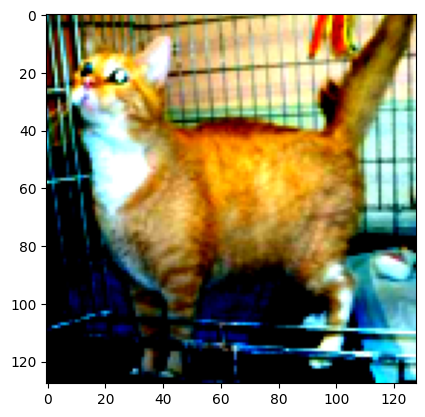

In [47]:
for image,label in train_dataloader:
  print(image.shape,label.shape)
  print(label[0].item())
  print(full_dataset.class_name[label[0].item()])
  plt.imshow(image[0].permute(1,2,0))
  break

In [48]:
print(full_dataset.class_name)

{0: 'dogs', 1: 'snakes', 2: 'cats'}


# Custom CNN Architecture

In [49]:

class CustomCNNClassifier(nn.Module):
  def __init__ (self,input_dim , num_classes):
    super(CustomCNNClassifier,self).__init__()
    self.input_dim = input_dim
    self.num_classes = num_classes


    self.conv_layer = nn.Sequential(

                                            # Block 1
        nn.Conv2d(3, 32, 3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.Conv2d(32, 32, 3, padding=1),   # تحسين مهم
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),

        # Block 2
        nn.Conv2d(32, 64, 3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.Conv2d(64, 64, 3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),

        # Block 3
        nn.Conv2d(64, 128, 3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.Conv2d(128, 128, 3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),

        # Block 4
        nn.Conv2d(128, 256, 3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.Conv2d(256, 256, 3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),

        # #c1
        # nn.Conv2d(3,32,kernel_size=3,stride=1,padding=1),
        # nn.BatchNorm2d(32),
        # nn.ReLU(),
        # nn.MaxPool2d(kernel_size=2,stride=2),

        # #c2
        # nn.Conv2d(32,64,kernel_size=3,stride=1,padding=1),
        # nn.BatchNorm2d(64),
        # nn.ReLU(),
        # nn.MaxPool2d(kernel_size=2,stride=2),

        # #c3
        # nn.Conv2d(64,128,kernel_size=3,stride=1,padding=1),
        # nn.BatchNorm2d(128),
        # nn.ReLU(),
        # nn.MaxPool2d(kernel_size=2,stride=2),

        # #c4
        # nn.Conv2d(128,256,kernel_size=3,stride=1,padding=1),
        # nn.BatchNorm2d(256),
        # nn.ReLU(),
        # nn.MaxPool2d(kernel_size=2,stride=2),


    )

    self.to_linear = None
    self._get_conv_output(self.input_dim)


    self.linear_layer = nn.Sequential(
        # nn.Linear(self.to_linear,512),
        # nn.ReLU(),
        # nn.Dropout(0.3),
        # nn.Linear(512,128),
        # nn.ReLU(),

        # nn.Linear(128,self.num_classes),

          nn.Linear(self.to_linear, 256),
          nn.ReLU(),
          nn.Dropout(0.4),

          nn.Linear(256, 128),
          nn.ReLU(),
          nn.Dropout(0.3),

          nn.Linear(128, num_classes),

    )



  def _get_conv_output(self,input_dim):
    with torch.no_grad():
      dummy_input = torch.zeros(1,3,input_dim,input_dim)
      output = self.conv_layer(dummy_input)
      self.to_linear = output.view(1,-1).size(1)

  def forward(self,x):
    x = self.conv_layer(x)
    x = x.view(x.size(0),-1)
    x = self.linear_layer(x)

    return x


In [50]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
model = CustomCNNClassifier(128,3).to(device)
print(model)

CustomCNNClassifier(
  (conv_layer): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1),

In [54]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters() ,lr= 0.001)

In [55]:

# training loop

epochs = 100

for epoch in range(epochs):
  model.train()
  running_loss = 0.0
  for image,label in tqdm(train_dataloader, desc="batch"):
    image = image.to(device)
    label = label.to(device)

    optimizer.zero_grad()
    outputs =model(image)

    loss = criterion(outputs,label)
    loss.backward()
    optimizer.step()

    running_loss+=loss.item()

  epoch_loss = running_loss/len(train_dataloader)

  print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")





batch: 100%|██████████| 75/75 [00:08<00:00,  9.20it/s]


Epoch 1/100, Loss: 0.2583


batch: 100%|██████████| 75/75 [00:08<00:00,  9.11it/s]


Epoch 2/100, Loss: 0.0822


batch: 100%|██████████| 75/75 [00:08<00:00,  9.11it/s]


...

Epoch 98/100, Loss: 0.0171


batch: 100%|██████████| 75/75 [00:08<00:00,  9.20it/s]


Epoch 99/100, Loss: 0.0618


batch: 100%|██████████| 75/75 [00:08<00:00,  9.20it/s]

Epoch 100/100, Loss: 0.0339


In [56]:
model.eval()
total_correct = 0
total_samples = 0
with torch.no_grad():


  for image,label in tqdm(test_dataloader, desc="batch"):
    image = image.to(device)
    label = label.to(device)

    outputs = model(image)
    _,predict = torch.max(outputs,1)

    total_correct += (predict == label).sum().item()
    total_samples += label.size(0)

print(f"Test Accuracy {100*total_correct/total_samples:.2f}%")

batch: 100%|██████████| 19/19 [00:01<00:00, 13.78it/s]

Test Accuracy 79.17%


In [57]:
torch.save(model.state_dict(), 'cnn_model.pth' )

In [58]:
from torch.cuda import is_available
class ImageClassifier:
  def __init__(self,model_path,class_name):
    self.model_path = model_path
    self.class_name = class_name
    self.device = ('cuda' if torch.cuda.is_available else 'cpu')
    self.model = CustomCNNClassifier(128,3).to(self.device)
    self.model.load_state_dict(torch.load(self.model_path))
    self.model.eval()
    self.transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),])


  def predict(self,image_path):
    image = Image.open(image_path).convert('RGB')
    input_tensor = self.transform(image).unsqueeze(0).to(self.device)

    with torch.no_grad():
      output = self.model(input_tensor)
      _,predict = torch.max(output,1)


    label = self.class_name[predict.item()]

    img = cv2.imread(image_path)
    cv2.putText(img, label, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
    cv2.imwrite("output_image.jpg",img)

    return label






In [59]:
model = ImageClassifier('/content/cnn_model.pth',full_dataset.class_name)
model.predict('/content/Animals/cats/0_0001.jpg')

'cats'